<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Understanding Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the cost function of a model by iteratively adjusting the model's parameters (weights and biases). It's a fundamental algorithm in machine learning and deep learning.

### How it Works:

1.  **Cost Function**: We start with a cost (or loss) function, which measures how well our model performs. The goal is to find the parameters that minimize this function.

2.  **Initialization**: The model's parameters (weights and biases) are initialized with some random values.

3.  **Iteration**: The algorithm then repeatedly takes steps proportional to the negative of the gradient of the function at the current point. This means it moves in the direction of the steepest descent.

    *   **Gradient**: The gradient is a vector of partial derivatives that points in the direction of the steepest increase of the cost function.
    *   **Negative Gradient**: Therefore, the negative gradient points in the direction of the steepest decrease.

4.  **Learning Rate (α)**: This is a crucial hyperparameter that determines the size of the steps taken during each iteration. A small learning rate can lead to slow convergence, while a large learning rate might cause the algorithm to overshoot the minimum or even diverge.

5.  **Update Rule**: For each parameter (θ):

    `θ_new = θ_old - α * ∇J(θ_old)`

    Where:
    *   `θ_new` are the updated parameters.
    *   `θ_old` are the current parameters.
    *   `α` is the learning rate.
    *   `∇J(θ_old)` is the gradient of the cost function `J` with respect to `θ` at the current `θ_old`.

6.  **Convergence**: The process continues until the algorithm converges to a minimum (local or global) of the cost function, typically when the change in parameters or the cost function itself becomes very small, or after a fixed number of iterations.

### Example: Linear Regression with Gradient Descent

Let's implement Gradient Descent from scratch to find the best-fit line for a simple linear regression problem. We'll try to fit a line `y = mx + b` to some synthetic data.

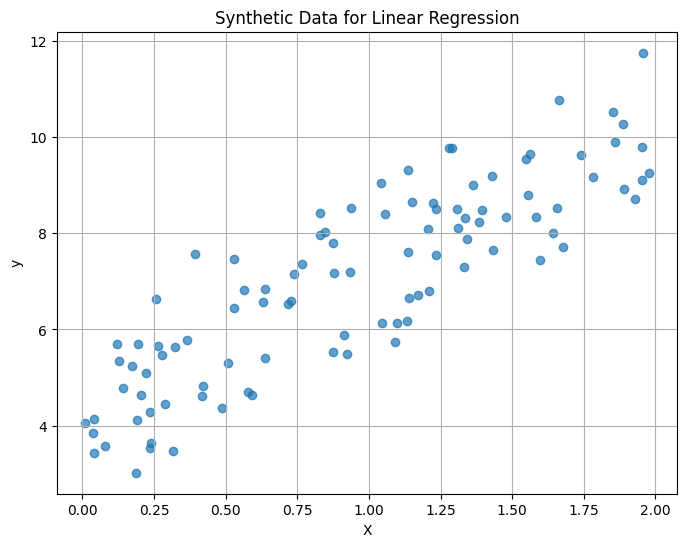

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1) # 100 random values between 0 and 2
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3X + noise

# Plot the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.7)
plt.title('Synthetic Data for Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()


In [2]:
# 2. Define the Cost Function (Mean Squared Error)
def cost_function(X, y, m, b):
    predictions = m * X + b
    return np.mean((predictions - y)**2)

# 3. Implement Gradient Descent
def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    m = 0.0 # Initialize slope
    b = 0.0 # Initialize intercept

    n_samples = len(y)

    cost_history = []
    m_history = []
    b_history = []

    for epoch in range(epochs):
        # Calculate predictions
        predictions = m * X + b

        # Calculate gradients
        # dJ/dm = (1/N) * sum(2 * (predictions - y) * X)
        # dJ/db = (1/N) * sum(2 * (predictions - y))
        dm = (2/n_samples) * np.sum((predictions - y) * X)
        db = (2/n_samples) * np.sum(predictions - y)

        # Update parameters
        m = m - learning_rate * dm
        b = b - learning_rate * db

        # Record cost and parameters
        current_cost = cost_function(X, y, m, b)
        cost_history.append(current_cost)
        m_history.append(m)
        b_history.append(b)

        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Cost: {current_cost:.4f}, m: {m:.4f}, b: {b:.4f}")

    return m, b, cost_history, m_history, b_history

# Run Gradient Descent
m_final, b_final, cost_hist, m_hist, b_hist = gradient_descent(X, y, learning_rate=0.01, epochs=1000)

print(f"\nFinal optimal m: {m_final:.4f}")
print(f"Final optimal b: {b_final:.4f}")


Epoch 100/1000, Cost: 1.1229, m: 3.4843, b: 3.5295
Epoch 200/1000, Cost: 1.0550, m: 3.3814, b: 3.7552
Epoch 300/1000, Cost: 1.0253, m: 3.2682, b: 3.8844
Epoch 400/1000, Cost: 1.0097, m: 3.1856, b: 3.9775
Epoch 500/1000, Cost: 1.0015, m: 3.1257, b: 4.0449
Epoch 600/1000, Cost: 0.9972, m: 3.0824, b: 4.0938
Epoch 700/1000, Cost: 0.9949, m: 3.0510, b: 4.1291
Epoch 800/1000, Cost: 0.9937, m: 3.0282, b: 4.1548
Epoch 900/1000, Cost: 0.9931, m: 3.0118, b: 4.1733
Epoch 1000/1000, Cost: 0.9928, m: 2.9998, b: 4.1868

Final optimal m: 2.9998
Final optimal b: 4.1868


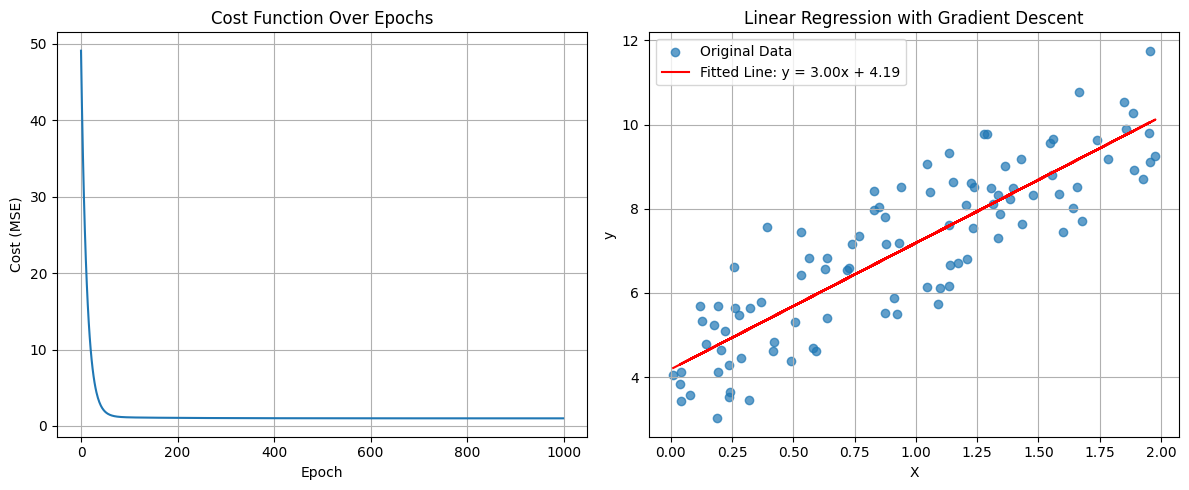

In [3]:
# 4. Visualize the results

# Plot the cost history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cost_hist)
plt.title('Cost Function Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.grid(True)

# Plot the final fitted line against the data
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.7, label='Original Data')
plt.plot(X, m_final * X + b_final, color='red', label=f'Fitted Line: y = {m_final:.2f}x + {b_final:.2f}')
plt.title('Linear Regression with Gradient Descent')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Different Types of Gradient Descent

There are several variations of Gradient Descent, each differing in how much data they use to compute the gradient of the cost function. This choice impacts the convergence speed, stability, and computational cost.

### 1. Batch Gradient Descent (BGD)

**Concept**: Batch Gradient Descent calculates the gradient of the cost function using *all* training examples in each iteration. This means that for every single update to the model's parameters, the entire dataset is processed.

**Characteristics**:
*   **Pros**:
    *   Guaranteed to converge to the global minimum for convex cost functions and to a local minimum for non-convex functions.
    *   The path to the minimum is typically smooth and stable.
*   **Cons**:
    *   Very slow for large datasets because it performs computations on the entire dataset for every parameter update.
    *   Each iteration can be computationally expensive.

**Our previous implementation was an example of Batch Gradient Descent.**

### 2. Stochastic Gradient Descent (SGD)

**Concept**: Stochastic Gradient Descent (SGD) calculates the gradient and updates the parameters for *each individual training example* at a time. Instead of summing up gradients from all examples, it makes an update for every single example.

**Characteristics**:
*   **Pros**:
    *   Much faster than BGD, especially for large datasets, as it performs frequent updates.
    *   Can escape local minima in non-convex cost functions due to its noisy updates.
*   **Cons**:
    *   The updates are noisy, leading to oscillations around the minimum rather than directly converging.
    *   Requires careful tuning of the learning rate, which might need to decrease over time (learning rate schedules).

Let's implement SGD.

In [8]:
# 3. Implement Stochastic Gradient Descent
def sgd(X, y, learning_rate=0.01, epochs=100):
    m = 0.0 # Initialize slope
    b = 0.0 # Initialize intercept
    n_samples = len(y)

    cost_history = []
    m_history = []
    b_history = []

    for epoch in range(epochs):
        # Shuffle the data for each epoch to ensure randomness
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        epoch_cost = 0
        for i in range(n_samples):
            # Extract scalar values from the 2D arrays
            xi = X_shuffled[i, 0]
            yi = y_shuffled[i, 0]

            # Calculate prediction for a single sample
            prediction = m * xi + b

            # Calculate gradients for a single sample (now scalar)
            dm = 2 * (prediction - yi) * xi
            db = 2 * (prediction - yi)

            # Update parameters (m and b remain scalars)
            m = m - learning_rate * dm
            b = b - learning_rate * db

            epoch_cost += (prediction - yi)**2

        # Record average cost for the epoch
        current_cost = epoch_cost / n_samples
        cost_history.append(current_cost)
        m_history.append(m)
        b_history.append(b)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Cost: {current_cost:.4f}, m: {m:.4f}, b: {b:.4f}")

    return m, b, cost_history, m_history, b_history

# Run Stochastic Gradient Descent
# We use fewer epochs and a potentially different learning rate for illustration
m_sgd, b_sgd, cost_hist_sgd, m_hist_sgd, b_hist_sgd = sgd(X, y, learning_rate=0.001, epochs=100)

print(f"\nFinal optimal m (SGD): {m_sgd:.4f}")
print(f"Final optimal b (SGD): {b_sgd:.4f}")


Epoch 10/100, Cost: 1.1421, m: 3.4891, b: 3.5203
Epoch 20/100, Cost: 1.0629, m: 3.3836, b: 3.7473
Epoch 30/100, Cost: 1.0310, m: 3.2682, b: 3.8774
Epoch 40/100, Cost: 1.0147, m: 3.1881, b: 3.9753
Epoch 50/100, Cost: 1.0053, m: 3.1319, b: 4.0472
Epoch 60/100, Cost: 1.0016, m: 3.0815, b: 4.0908
Epoch 70/100, Cost: 0.9993, m: 3.0528, b: 4.1291
Epoch 80/100, Cost: 0.9981, m: 3.0270, b: 4.1523
Epoch 90/100, Cost: 0.9973, m: 3.0149, b: 4.1746
Epoch 100/100, Cost: 0.9961, m: 2.9947, b: 4.1816

Final optimal m (SGD): 2.9947
Final optimal b (SGD): 4.1816


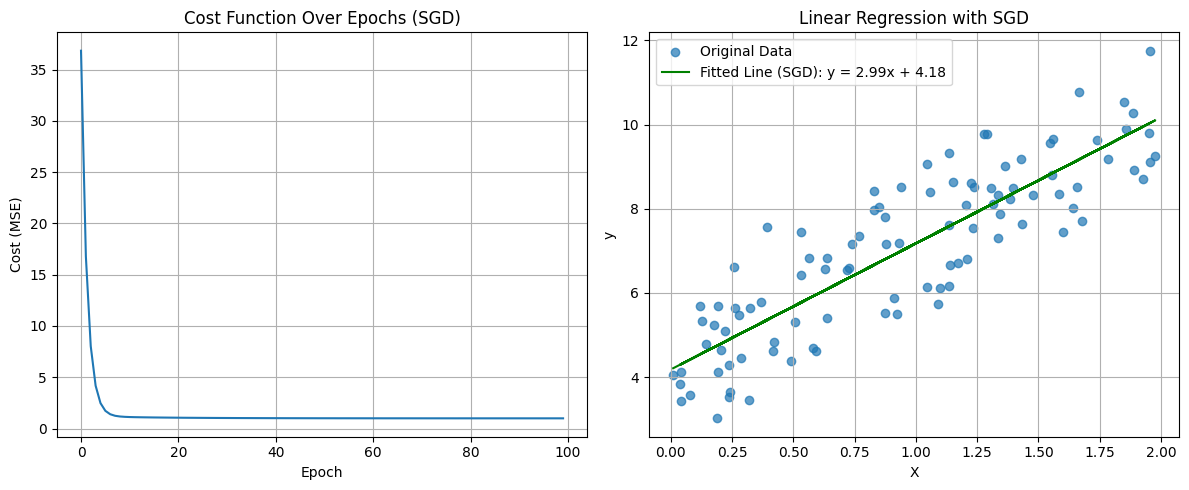

In [9]:
# Visualize SGD results

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cost_hist_sgd)
plt.title('Cost Function Over Epochs (SGD)')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.7, label='Original Data')
plt.plot(X, m_sgd * X + b_sgd, color='green', label=f'Fitted Line (SGD): y = {m_sgd:.2f}x + {b_sgd:.2f}')
plt.title('Linear Regression with SGD')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### 3. Mini-Batch Gradient Descent

**Concept**: Mini-Batch Gradient Descent is a compromise between BGD and SGD. It updates parameters using a small 'mini-batch' of training examples (typically between 10 and 1,000 samples) at each iteration, rather than the entire dataset or a single example.

**Characteristics**:
*   **Pros**:
    *   Balances the stability of BGD with the efficiency of SGD.
    *   More stable convergence than SGD, and faster than BGD.
    *   Leverages highly optimized matrix operations, often leading to efficient computation, especially with GPUs.
*   **Cons**:
    *   Requires tuning of the batch size, which can affect convergence.
    *   The cost function's oscillation is less than SGD but more than BGD.

Let's implement Mini-Batch Gradient Descent.

In [6]:
# 4. Implement Mini-Batch Gradient Descent
def mini_batch_gd(X, y, learning_rate=0.01, epochs=100, batch_size=16):
    m = 0.0 # Initialize slope
    b = 0.0 # Initialize intercept
    n_samples = len(y)

    cost_history = []
    m_history = []
    b_history = []

    n_batches = n_samples // batch_size

    for epoch in range(epochs):
        # Shuffle the data for each epoch
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        epoch_cost = 0
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            # Calculate predictions for the mini-batch
            predictions = m * X_batch + b

            # Calculate gradients for the mini-batch
            dm = (2/len(y_batch)) * np.sum((predictions - y_batch) * X_batch)
            db = (2/len(y_batch)) * np.sum(predictions - y_batch)

            # Update parameters
            m = m - learning_rate * dm
            b = b - learning_rate * db

            epoch_cost += np.sum((predictions - y_batch)**2)

        # Record average cost for the epoch
        current_cost = epoch_cost / n_samples
        cost_history.append(current_cost)
        m_history.append(m)
        b_history.append(b)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Cost: {current_cost:.4f}, m: {m:.4f}, b: {b:.4f}")

    return m, b, cost_history, m_history, b_history

# Run Mini-Batch Gradient Descent
m_mbgd, b_mbgd, cost_hist_mbgd, m_hist_mbgd, b_hist_mbgd = mini_batch_gd(X, y, learning_rate=0.01, epochs=100, batch_size=16)

print(f"\nFinal optimal m (Mini-Batch GD): {m_mbgd:.4f}")
print(f"Final optimal b (Mini-Batch GD): {b_mbgd:.4f}")


Epoch 10/100, Cost: 1.3715, m: 3.4090, b: 3.3131
Epoch 20/100, Cost: 1.0905, m: 3.4811, b: 3.6630
Epoch 30/100, Cost: 1.0537, m: 3.3817, b: 3.7881
Epoch 40/100, Cost: 1.0341, m: 3.2862, b: 3.8605
Epoch 50/100, Cost: 1.0173, m: 3.2279, b: 3.9536
Epoch 60/100, Cost: 1.0153, m: 3.1828, b: 4.0143
Epoch 70/100, Cost: 1.0030, m: 3.1158, b: 4.0515
Epoch 80/100, Cost: 1.0062, m: 3.0506, b: 4.0564
Epoch 90/100, Cost: 0.9986, m: 3.0387, b: 4.0880
Epoch 100/100, Cost: 0.9979, m: 3.0389, b: 4.1488

Final optimal m (Mini-Batch GD): 3.0389
Final optimal b (Mini-Batch GD): 4.1488


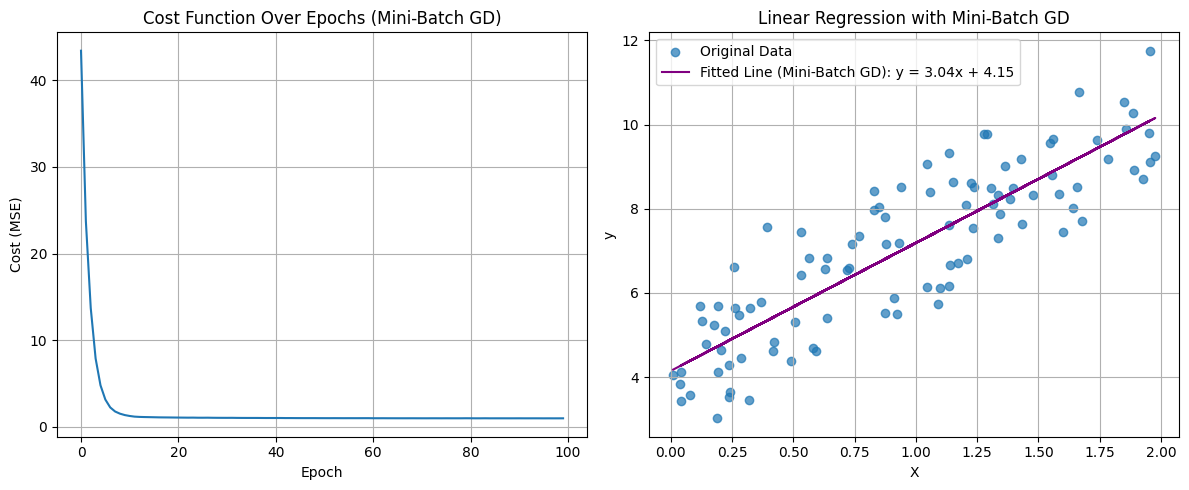

In [7]:
# Visualize Mini-Batch GD results

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cost_hist_mbgd)
plt.title('Cost Function Over Epochs (Mini-Batch GD)')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.7, label='Original Data')
plt.plot(X, m_mbgd * X + b_mbgd, color='purple', label=f'Fitted Line (Mini-Batch GD): y = {m_mbgd:.2f}x + {b_mbgd:.2f}')
plt.title('Linear Regression with Mini-Batch GD')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Comparison of Convergence Speed

Let's visually compare the cost function history for Batch Gradient Descent (BGD), Stochastic Gradient Descent (SGD), and Mini-Batch Gradient Descent (MBGD) to understand their convergence speeds and characteristics.

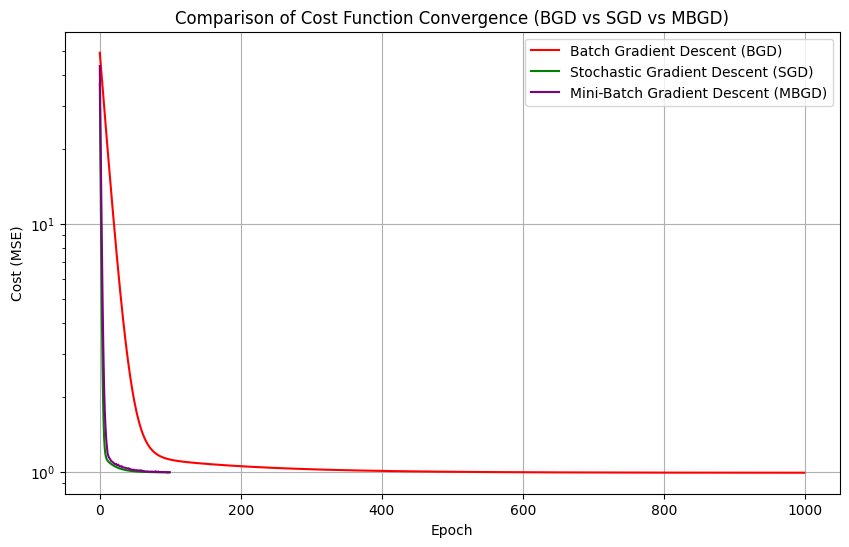

In [10]:
plt.figure(figsize=(10, 6))

# Plot Batch Gradient Descent cost history
plt.plot(cost_hist, label='Batch Gradient Descent (BGD)', color='red')

# Plot Stochastic Gradient Descent cost history
# Note: SGD was run for 100 epochs, BGD for 1000. We'll adjust the x-axis for comparison if necessary,
# but for direct comparison, we plot the available epochs.
plt.plot(range(len(cost_hist_sgd)), cost_hist_sgd, label='Stochastic Gradient Descent (SGD)', color='green')

# Plot Mini-Batch Gradient Descent cost history
plt.plot(range(len(cost_hist_mbgd)), cost_hist_mbgd, label='Mini-Batch Gradient Descent (MBGD)', color='purple')

plt.title('Comparison of Cost Function Convergence (BGD vs SGD vs MBGD)')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.legend()
plt.grid(True)
plt.yscale('log') # Use a logarithmic scale for y-axis to better visualize initial large drops and later smaller oscillations
plt.show()


### Observations from the Convergence Plot:

*   **Batch Gradient Descent (BGD)**: Shows a very smooth and consistent decrease in the cost function. It typically takes many epochs to converge, but its path is stable and directly approaches the minimum.

*   **Stochastic Gradient Descent (SGD)**: The cost function for SGD is much noisier and fluctuates significantly compared to BGD. This is due to the frequent updates based on single training examples, which can cause oscillations. However, it often makes rapid progress initially, especially with large datasets, and can escape local minima more easily.

*   **Mini-Batch Gradient Descent (MBGD)**: Strikes a balance between BGD and SGD. Its cost function convergence is smoother than SGD but not as perfectly smooth as BGD. It generally converges faster than BGD and more stably than SGD, benefiting from both the frequent updates of SGD and the gradient averaging of BGD. The noise in the updates is reduced because the gradients are averaged over a small batch rather than a single example.